## Are We Alone in Space?
### Analyzing NASA’s Exoplanet Data with Python

---

In this project, we’ll explore relationships in real scientific data from NASA’s Exoplanet Archive.

Our goal is to practice exploratory data analysis (EDA): visualizing data, computing basic metrics, and interpreting patterns carefully.

---


### Goals

**1. Load the Data**  

**2. Practice Pure Python Skills**  

**3. Plot Relationships**  

**4. Compute Descriptive Statistics**  



### Questions

These are some of the questions we will tackle:

**1. Planet Size vs. Planet Mass**  
Common sense would suggest that larger planets also have more mass, but this might not be the case for gas planets. We will explore this relationship.

**2. Discovery Year vs. Planet Size**  
Sometimes relationships between 2 variables are more complex. There appears to be a correlation between discovery year and planets size (as better instruments might enable the discovery of smaller planets). We will analyze whether this is true.

**3. Discovery Methods**  
Different discovery methods have been used over the years. We will assess which one of them has found the most planets.

---

## Column descriptions 
Below are the columns we use in the notebook and what they represent.

- **pl_name:** Planet name (string)
- **pl_rade:** Planet radius in Earth radii (float)
- **pl_bmasse:** Planet mass in Earth masses (float)
- **discoverymethod:** Discovery method (categorical — e.g., Transit, Radial Velocity)
- **hostname:** Host star name (string)
- **disc_year:** Discovery year (datetime)


---
## 1. Load Data
In this section we import libraries and load the dataset using `pandas`. We’ll display the first few rows and some basic information about the dataset.

In [18]:
# ============================================================
# Import libraries and load the dataset
#
# ============================================================
from pathlib import Path

# Import that pandas library as pd
import pandas as pd
import hvplot.pandas
import matplotlib.pyplot as plt
import seaborn as sns

# Run this line to load in the data
df = pd.read_csv(Path(r'udacity_exoplanet.csv'))

# Print out the first 5 rows to verify it was loaded correctly
df.head()


,pl_name,pl_rade,pl_bmasse,pl_orbper,discoverymethod,hostname,disc_year
0,55 Cnc e,1.933500,8.117035,0.736546,Radial Velocity,55 Cnc,2004
1,AU Mic b,4.070000,17.000000,8.463080,Transit,AU Mic,2020
2,AU Mic c,2.790000,13.600000,18.859018,Transit,AU Mic,2021
3,BD+20 594 b,2.355454,19.274050,41.685500,Transit,BD+20 594,2016
4,BD-14 3065 b,21.150600,3932.000000,4.288971,Transit,BD-14 3065 A,2024


## 2. Inspect the DataFrame
Use a suitable pandas method to inspect column dtypes and missing values.

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1653 entries, 0 to 1652
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          1653 non-null   str    
 1   pl_rade          1653 non-null   float64
 2   pl_bmasse        1653 non-null   float64
 3   pl_orbper        1653 non-null   float64
 4   discoverymethod  1653 non-null   str    
 5   hostname         1653 non-null   str    
 6   disc_year        1653 non-null   int64  
dtypes: float64(3), int64(1), str(3)
memory usage: 90.5 KB


## 3. Examine Numeric Summaries

Use a suitable pandas method to inspect numeric columns and distributions (e.g. count, mean, median, mode, etc.)


In [7]:
df.describe()

,pl_rade,pl_bmasse,pl_orbper,disc_year
count,1653.000000,1653.000000,1.653000e+03,1653.000000
mean,7.866053,353.145978,2.518816e+05,2017.535995
std,5.997161,847.574427,9.890363e+06,5.036375
min,0.296310,0.100000,1.120067e-01,1999.000000
25%,2.395737,9.130000,3.196884e+00,2014.000000
50%,6.410000,67.400000,5.416108e+00,2018.000000
75%,12.860967,317.830000,1.412846e+01,2022.000000
max,65.850000,8899.195396,4.020000e+08,2025.000000


## 4. Create a Sorted List of Unique Planet and Host Star Names

**Instruction:**
- Do NOT use pandas unique()/value_counts().
- Use only basic Python: lists, sets, sorted.

**Goal:**
Show the total unique counts and the first 20 names as samples.

### Part A - Follow these steps for the Planet Names

- Step1: convert the `pl_name` column into a plain Python list


- Step2: remove duplicates using a set, then sort the results into a list

- Step3: print the total number of unique planets


- Step4: print a small sample (first 20) of the unique planet names

In [42]:
# Step1: convert the `pl_name` column into a plain Python list
raw_names = df['pl_name'].tolist()
print(f'Plain list: {raw_names}')

# Step2: 
unique_planets = set(raw_names)
unique_planets = sorted(unique_planets)
print(f'Sorted and duplicates removed: {unique_planets}')

# Step3: 
qtd_planets = len(unique_planets)
print(f'Number of unique planets: {qtd_planets}')

# Step4: 
print(f'First 20 planets: {unique_planets[:20]}')


Plain list: ['55 Cnc e', 'AU Mic b', 'AU Mic c', 'BD+20 594 b', 'BD-14 3065 b', 'CFHTWIR-Oph 98 b', 'COCONUTS-2 b', 'CoRoT-1 b', 'CoRoT-10 b', 'CoRoT-11 b', 'CoRoT-12 b', 'CoRoT-13 b', 'CoRoT-14 b', 'CoRoT-16 b', 'CoRoT-17 b', 'CoRoT-18 b', 'CoRoT-19 b', 'CoRoT-2 b', 'CoRoT-20 b', 'CoRoT-21 b', 'CoRoT-22 b', 'CoRoT-23 b', 'CoRoT-24 b', 'CoRoT-24 c', 'CoRoT-25 b', 'CoRoT-26 b', 'CoRoT-27 b', 'CoRoT-28 b', 'CoRoT-29 b', 'CoRoT-3 b', 'CoRoT-30 b', 'CoRoT-31 b', 'CoRoT-32 b', 'CoRoT-35 b', 'CoRoT-36 b', 'CoRoT-4 b', 'CoRoT-5 b', 'CoRoT-6 b', 'CoRoT-7 b', 'CoRoT-8 b', 'CoRoT-9 b', 'DS Tuc A b', 'EPIC 201595106 b', 'EPIC 211945201 b', 'EPIC 220674823 b', 'EPIC 220674823 c', 'EPIC 229004835 b', 'EPIC 246851721 b', 'EPIC 248847494 b', 'EPIC 249893012 b', 'EPIC 249893012 c', 'EPIC 249893012 d', 'G 9-40 b', 'GJ 1132 b', 'GJ 1214 b', 'GJ 1252 b', 'GJ 143 b', 'GJ 3090 b', 'GJ 341 b', 'GJ 3470 b', 'GJ 3473 b', 'GJ 357 b', 'GJ 367 b', 'GJ 3929 b', 'GJ 414 A b', 'GJ 414 A c', 'GJ 436 b', 'GJ 486 b', 

### Part B - Follow these steps for the Host Star Names

- Step1: convert the `hostname` column into a plain Python list


- Step2: remove duplicates and sort the host star names


- Step3: print the total number of unique host stars


- Step4: print a small sample (first 20) of the unique host star names

In [43]:
#TODO:  Create a sample of 20 unique host star names

# Step1: convert the `hostname` column into a plain Python list
raw_hosts = df['hostname'].tolist()
print(f'Plain list: {raw_hosts}')

# Step2: 
unique_hosts = sorted(set(raw_hosts))
print(f'Sorted and duplicates removed: {unique_hosts}')

# Step3: 
qtd_hosts = len(unique_hosts)
print(f'Number of unique host stars: {qtd_hosts}')

# Step4:
print(f'First 20 host stars: {unique_hosts[:20]}')

Plain list: ['55 Cnc', 'AU Mic', 'AU Mic', 'BD+20 594', 'BD-14 3065 A', 'CFHTWIR-Oph 98 A', 'COCONUTS-2 A', 'CoRoT-1', 'CoRoT-10', 'CoRoT-11', 'CoRoT-12', 'CoRoT-13', 'CoRoT-14', 'CoRoT-16', 'CoRoT-17', 'CoRoT-18', 'CoRoT-19', 'CoRoT-2', 'CoRoT-20', 'CoRoT-21', 'CoRoT-22', 'CoRoT-23', 'CoRoT-24', 'CoRoT-24', 'CoRoT-25', 'CoRoT-26', 'CoRoT-27', 'CoRoT-28', 'CoRoT-29', 'CoRoT-3', 'CoRoT-30', 'CoRoT-31', 'CoRoT-32', 'CoRoT-35', 'CoRoT-36', 'CoRoT-4', 'CoRoT-5', 'CoRoT-6', 'CoRoT-7', 'CoRoT-8', 'CoRoT-9', 'DS Tuc A', 'EPIC 201595106', 'EPIC 211945201', 'EPIC 220674823', 'EPIC 220674823', 'EPIC 229004835', 'EPIC 246851721', 'EPIC 248847494', 'EPIC 249893012', 'EPIC 249893012', 'EPIC 249893012', 'G 9-40', 'GJ 1132', 'GJ 1214', 'GJ 1252', 'GJ 143', 'GJ 3090', 'GJ 341', 'GJ 3470', 'GJ 3473', 'GJ 357', 'GJ 367', 'GJ 3929', 'GJ 414 A', 'GJ 414 A', 'GJ 436', 'GJ 486', 'GJ 806', 'GJ 9827', 'GJ 9827', 'GJ 9827', 'GPX-1', 'Gaia-1', 'Gaia-2', 'Gliese 12', 'HAT-P-1', 'HAT-P-11', 'HAT-P-12', 'HAT-P-13'

## 5. On average, how many planets does each star have?

**Instruction:**
Use only basic Python (no pandas or polar aggregations)

**Hint**
Each row represents one planet orbiting one host star. Starter code for
Steps 1 and 2 have been given to you. 

- Step1: create a dictionary to count how many planets orbit each star

- Step2: loop over each host star entry (one per planet)
    - If star is in the dictionary, increment its count otherwise, add the star to the dictionary with a count of 1

- Step3: compute the total number of planets

- Step4: compute the total number of unique host stars

- Step5: compute the average number of planets per star and print the result

In [41]:
# Step1: create a dictionary to count how many planets orbit each star
planets_per_star = {}

# Step2: loop over each host star entry -- finish this step's code
for host in raw_hosts:
    if host in planets_per_star:
        planets_per_star[host] += 1
    else:
        planets_per_star[host] = 1

# Step3: 
total_planets = len(raw_hosts)
print(f"Number of planets: {total_planets}")

# Step4: 
total_stars = len(planets_per_star)
print(f"Number of stars: {total_stars}")

# Step5: 
average = total_planets / total_stars
print(f"Average planets per star: {average:.2f}")

Number of planets: 1653
Number of stars: 1272
Average planets per star: 1.30


## 6. Which THREE host stars have the MOST known planets?
**Instruction:**
Use only basic Python (lists, dictionaries, sorted).

- Step1: convert the dictionary into a list of (star, planet_count) pairs


- Step2: sort the list by planet count (highest first)


- Step3: select the top three stars


- Step4: print the results


In [46]:
# Step1: convert the dictionary into a list of (star, planet_count) pairs
star_planet_pairs = list(planets_per_star.items())

# Step2: 
star_planet_pairs = sorted(
    star_planet_pairs,
    key=lambda pair: pair[1],
    reverse=True
)

# Step3: 
top_three = star_planet_pairs[:3]

# Step4: 
print("< Top 3 host stars >")
for star, count in top_three:
    print(f"{star}: {count} planets")


< Top 3 host stars >
TRAPPIST-1: 7 planets
HD 110067: 6 planets
K2-138: 6 planets


## 7. Visual Inspection

### Histogram of planet radii
**Instruction:**

Create a histogram of planet radii using seaborn and matplotlib. Use log-scale if the distribution is skewed. Be sure to add a title and label the axes.

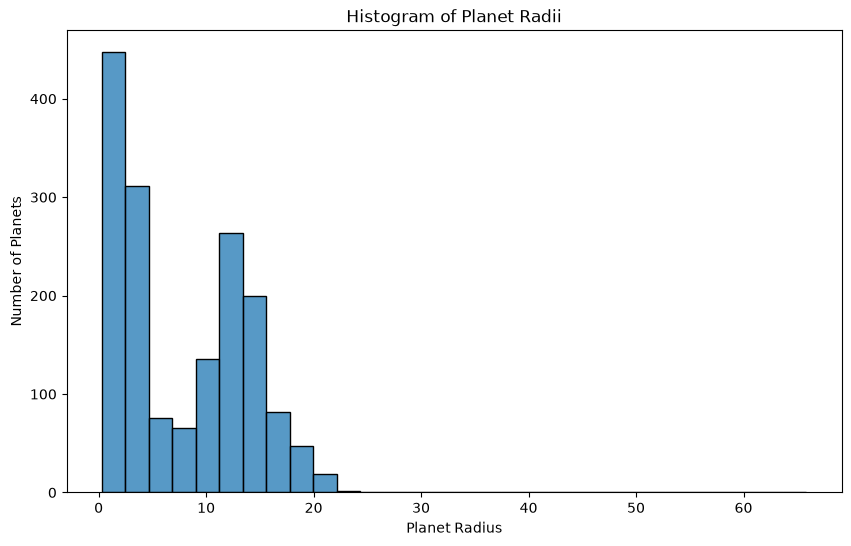

In [4]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="pl_rade",
    bins=30
)

plt.title("Histogram of Planet Radii")
plt.xlabel("Planet Radius")
plt.ylabel("Number of Planets")

plt.show()

### Bar Chart of Top Discovery Methods 
**Instruction:**

Count the top discovery methods and plot them as a horizontal bar chart.
- Assign y-variable to hue (required for palette)
- Hide legend (it would be redundant)
- Be sure to add a title and label the axes.

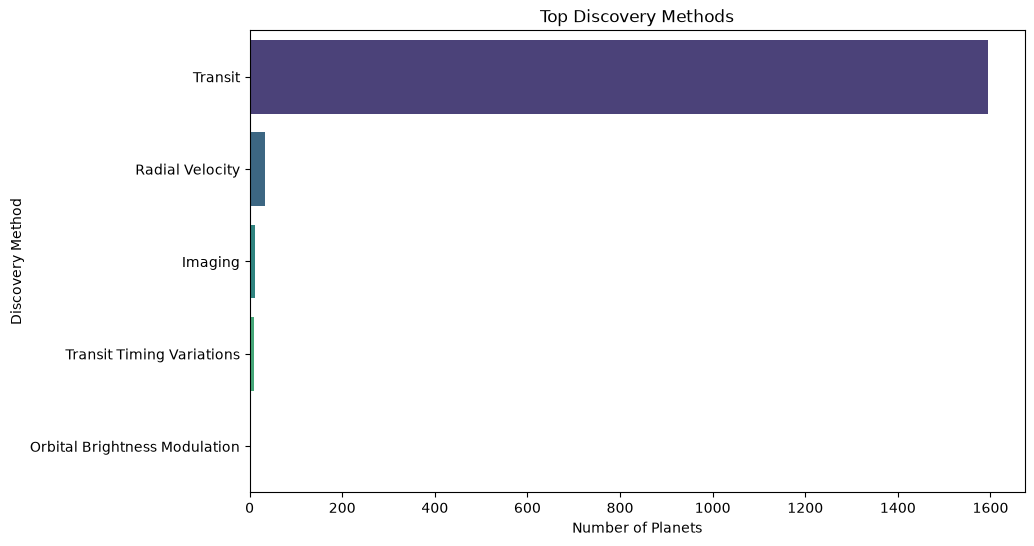

In [16]:
# Count the discovery methods
method_counts = df["discoverymethod"].value_counts()

# Create the figure
plt.figure(figsize=(10, 6))

# Horizontal bar chart
sns.barplot(
    x=method_counts.values,     # x = quantity
    y=method_counts.index,      # y = method name
    hue=method_counts.index,    # FutureWarning: Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0.
    palette="viridis",
    legend=False
)

# Title and labels
plt.title("Top Discovery Methods")
plt.xlabel("Number of Planets")
plt.ylabel("Discovery Method")

plt.show()

### Scatter plot of Radius vs. Mass
**Instruction:**
Use hvplot.pandas to make an interactive scatter plot of planet radius vs planet mass. 
- Optionally color by discovery method.
- Be sure to add a title and label the axes.

In [22]:
df.hvplot.scatter(
    x="pl_rade",
    y="pl_bmasse",
    by="discoverymethod",
    hover_cols=["pl_name"],
    width=800,
    height=500,
    title="Planet Radius vs Planet Mass",
    xlabel="Planet Radius",
    ylabel="Planet Mass"
)

:NdOverlay   [discoverymethod]
   :Scatter   [pl_rade]   (pl_bmasse,pl_name)

### Boxplot of Orbital Periods
**Instruction:**
Create an interactive boxplot using hvplot.pandas of orbital periods (on a log scale) to inspect distribution and outliers.Be sure to add a title and label the axes.

In [24]:
df.hvplot.box(
    y="pl_orbper",
    logy=True,
    width=600,
    height=500,
    title="Distribution and Outliers",
    ylabel="Orbital Period"
)

:BoxWhisker   (pl_orbper)

### Scatter plot of Radius vs. Discovery Year

**Instruction:**
Use hvplot pandas to create a scatter plot of planet radius versus discovery year to explore trends over time. Be sure to add a title and label the axes.

In [26]:
df.hvplot.scatter(
    x="disc_year",
    y="pl_rade",
    hover_cols=["pl_name"],
    width=800,
    height=500,
    title="Planet Radius vs Discovery Year",
    xlabel="Discovery Year",
    ylabel="Planet Radius"
)

:Scatter   [disc_year]   (pl_rade,pl_name)

## 8. Variable Relationships and Statistics

### Correlation Matrix of Numeric Variables 

**Instruction:**
Use the pandas library to create **one** correlation matrix for the numeric variables of planet radius and mass to identify the relationship between these two variables. 


In [ ]:
#TODO:  Create correlation matrix

### Create a scatter plot of radius versus discovery year to explore trends over time 

**Instruction:**
- Use hvplot pandas to create a scatter plot of radius versus discovery year 
- Be sure to add a title and label the axes 

In [ ]:
#TODO: Create a scatter of planet radius per discovery year

### Compute radius statistics (mean and median) by discovery year

**Instruction:**
- For each discovery year compute the **mean** and **median** of planet radius (`pl_rade`) 
- Sort the results by year in ascending order.
- Use pandas groupby and aggregations
- Show the first 10 years as a sample

In [7]:
#TODO: Compute mean and median of planet radius per discovery year




#Show the first 10 years as a sample


## 9. Interactive visualization of radius statistics over time
Create an interactive plot using hvplot to visualize how mean and median planet radius change over discovery years. This interactive visualization allows you to zoom, pan, and hover to see exact values.

- Use hvplot.line() to create separate line plots for each statistic,then overlay them using the * operator. 
- Add appropriate labels, colors, and formatting options.
- Be sure to add a title and label the axes.

In [ ]:
#TODO:  Create Interactive Line Plots

radius_col = 'pl_rade'
year_col = 'disc_year'

#compute mean and median of planet radius per discovery year 

#create interactive plots using hvplot 

#combine and overlay the plots

## 10.  3D Visualization: Exploring Planet Characteristics

Create an interactive 3D scatter plot using plotly.express package to visualize relationships between planet radius, mass, and orbital period simultaneously. This allows you to explore complex relationships between these fundamental planet characteristics and see how they vary by discovery method.

- Be sure to import the plotly.express library 
- Prepare the data by removing duplicates before creating the scatter plot 
- Color the points by discovery method 
- Use logarithmic scales for all three axes to handle the wide range of values
- Use fig.update_traces() to adjust marker size for better visibility.
- Be sure to add a title and label the axes.

In [ ]:
#TODO: Create Interactive Plot in plotly.express